# Inleiding

In deze opdracht gaan jullie je scripts van vorige week verbeteren en uitbreiden. Dat gezegd, hebben we liever dat je ingeleverd Jupyter Notebook bestanden niet super lang worden, dus in plaats van het toevoegen van nieuwen cellen in jullie bestanden van Opdracht 1, gebruik alsjeblieft deze sjabloon als basis. Dan, in de relevante plekken, alleen de cellen van de vorige opdracht die echt voor deze opdracht nodig zijn kopie/plakken. Bijvoorbeeld, hoewel dataverkenning toch belangrijk is, hebben jullie hopelijk al genoeg daarvan gedaan, en dus is het niet nodig om die code en plotjes hierbij ook te hebben. 

Hier is een lijst van de elementen die je waarschijnlijk willen overdragen:
1. het inlezen/splitsen van jouw datasets
2. de definitieve versie van jouw regressie/classificatie modellen (niet de voorbereiding stappen)
3. blijf dezelfde twee gekozen algoritmes gebruiken

Let op: In tegenstelling tot de eerste opdracht, voor deze en de resterende 2 opdrachten worden jullie peer reviews alleen beoordeeld op een ja of nee basis. 

Zoals geschreven in de vakbeschrijving:

"Het niet op tijd of lui maken van een individuele peer review resulteert in een reductie van 0,5 punt voor het cijfer van de bijhorende opdracht van de reviewer."

Gezien dat jullie peer reviews zijn sowieso kwalitatief beoordeeld voor Opdracht 1, is deze halfpunt reductie alleen voor Opdrachten 2 t/m 4 geldig. 

### Algemene Coderen Conventies

De volgorde van het python script is belangrijk. Zo zorg je bijvoorbeeld altijd dat eerst de benodigde packages worden ingeladen geïnstalleerd en geïmporteerd). Verder is het goed om van tevoren jouw working directory te controleren. 

Schrijf het python script daarom met een duidelijke indeling van met verschillende stappen. Bij elke stap dient toelichting worden gegeven:
1. Wat is het doel van deze stap?
2. Wat is de input van deze stap?
3. Wat is de output van deze stap en waar heb je deze output hierna nog nodig?

Hieronder voorbeelden van de verschillende punten hierboven.

In [ ]:
### Voorbeeld: Standaard Imports
import numpy as np
import matplotlib.pyplot as plt


### Controleer Working Directory
import os
print(os.getcwd())

# Pas je working directory aan indien gewenst
# path = 'C:\\Users\\rburrus\\Desktop\\Jupyter Notebook' # zet hier wat voor jou goed is
# os.chdir(path)
# print(os.getcwd())


### Voorbeeld: Functie met Beschrijving Schrijven

def voorbeeld_functie(parameter1, parameter2 = 2):
    # Doel: dit functie maakt een bepaalde berekening
    # In: parameter1 (float), parameter2 (integer)
    # Uit: parameter1 macht parameter2 (standaard macht 2)
    
    return parameter1 ** parameter2

# Deelopdracht 1/2 - Regressie Model (Huizenprijzen)

Let op: de bedoeling is dat jullie hetzelfde regressie algoritme van Opdracht 1 blijven gebruiken (dus niet een nieuwe). 

### Theorievragen

Kies twee verschillende prestatiemetrics voor jouw gekozen regressie algoritme.
Begin met het beantwoorden van een aantal vragen over deze prestatiemetrics.

1. Waarom heb je deze prestatiemetrics gekozen?

2. Wat zijn de voor- en nadelen van de eerste prestatiemetric?

3. Wat zijn de voor- en nadelen van de tweede prestatiemetric?

#### Beantwoord nu een aantal vragen over hyperparameters voor jouw gekozen regressie algoritme.

4. Welke hyperparameters in je model kun je instellen (aan welke knoppen kan je draaien)? 

5. Leg uit wat een verandering van de waarde met het model doet (per hyperparameter).

6. Wat zouden logische waarden kunnen zijn (per hyperparameter)?

## Code

Zoals bij Opdracht 1, voor het regressie model kunnen jullie deze dataset gebruiken:

https://www.kaggle.com/c/house-prices-advanced-regression-techniques

Als je het niet al hebben gedaan, splits je dataset in een train en een test (validatie) set.

### Prestatiemetrics

Bereken 2 prestatiemetrics op de traindata en op de testdata. Zijn er grote verschillen? Zo ja, hoe zou dat kunnen komen?

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De prestatiemetrics van de modellen zijn berekend. Er wordt toegelicht wat waarde van de metric betekend. Voordelen en nadelen van de gekozen metrics worden benoemd."

Let op: Je kan deze vraag (en soortgelijke vragen hieronder) beantwoorden via zowel aanvullende Markdown cellen (voor tekstuele antwoorden) als Code cellen (voor jouw code zelf, met commentaar erbij). Gebruik gewoon wat je het best helpt om de vraag te beantwoorden. 

(voorbeeld Markdown cell)

In [5]:
# === STAP 2: Data Laden ===
# Doel: Train dataset laden en voorbereiden
# In: CSV file van Kaggle
# Uit: X (features), y (target), en gesplitste train/test datasets

# Data laden
data = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

# Controleer data
print("Data shape (origineel):", data.shape)
print(f"Missing values: {data.isnull().sum().sum()} totale")

# === STAP 3: Data Voorbereiding ===
# Doel: Dataset voorbereiden en missing values imputeren
# In: Dataset met NaN waarden
# Uit: X (features), y (target) met geïmputeerde waarden

# Voorbereiding: verwijder ID kolom en selecteer features
X = data.drop(['Id', 'SalePrice'], axis=1)
y = data['SalePrice']

# Zorg dat we alleen numerieke features gebruiken
X = X.select_dtypes(include=[np.number])

print(f"\nData shape (voor imputation): {X.shape}")
print(f"Missing values in features: {X.isnull().sum().sum()}")

# Impute missing values met het gemiddelde (median kan ook)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print(f"Missing values na imputation: {X.isnull().sum().sum()}")
print(f"Number of features: {X.shape[1]}")

Data shape (origineel): (1460, 81)
Missing values: 7829 totale

Data shape (voor imputation): (1460, 36)
Missing values in features: 348
Missing values na imputation: 0
Number of features: 36


In [3]:
# === STAP 4: Train/Test Split ===
# Doel: Dataset splitsen in 80% train en 20% test
# In: X (features), y (target)
# Uit: X_train, X_test, y_train, y_test

# Split in train (80%) en test (20%) set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% voor testing
    random_state=42  # voor reproducibility
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Train/Test ratio: {X_train.shape[0]}/{X_test.shape[0]}")


# === STAP 5: Model Trainen ===
# Doel: RandomForestRegressor trainen
# In: X_train, y_train
# Uit: Getraind model

model = RandomForestRegressor(
    n_estimators=100,      # aantal decision trees
    max_depth=20,          # maximale diepte van trees
    min_samples_split=5,   # minimaal samples om te splitten
    random_state=42,       # voor reproducibility
    n_jobs=-1              # parallelle processing
)

model.fit(X_train, y_train)

print("✓ RandomForest Model succesvol getraind!")
print(f"  Algorithm: RandomForestRegressor")
print(f"  Number of trees: {model.n_estimators}")
print(f"  Number of features: {model.n_features_in_}")
print(f"  Max depth per tree: {model.max_depth}")

# === STAP 6: Voorspellingen Maken ===
# Doel: Predictions maken op zowel train als test data
# In: Getraind model, X_train, X_test
# Uit: y_pred_train, y_pred_test

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("✓ Voorspellingen gemaakt voor train en test set!")


Train set size: 1168 samples
Test set size: 292 samples
Train/Test ratio: 1168/292
✓ RandomForest Model succesvol getraind!
  Algorithm: RandomForestRegressor
  Number of trees: 100
  Number of features: 36
  Max depth per tree: 20
✓ Voorspellingen gemaakt voor train en test set!


PRESTATIEMETRICS — TRAIN VS. TEST

Metric 1: Mean Absolute Error (MAE)
  Train MAE : $ 6,759.40
  Test MAE  : $ 18,190.97
  Verschil  : $ 11,431.57

Metric 2: R²-score
  Train R² : 0.9782
  Test R²  : 0.8856
  Verschil : 0.0926


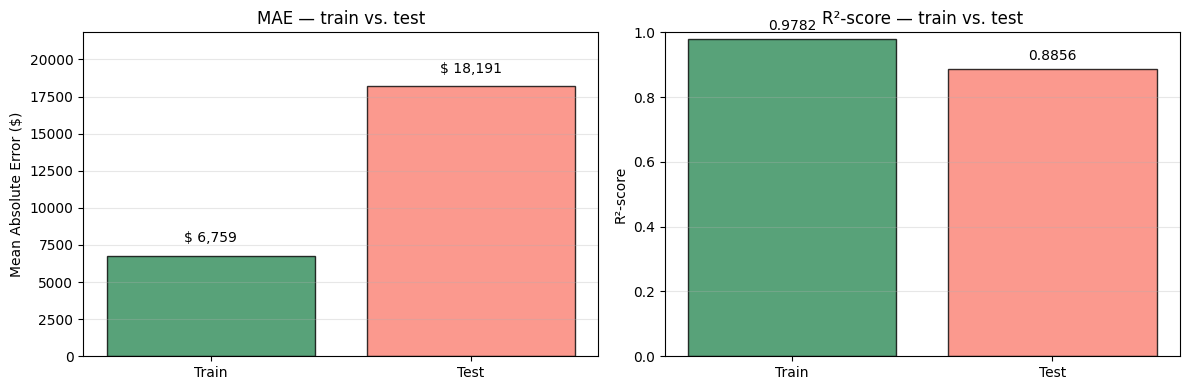

In [19]:
# === STAP 7: Prestatiemetrics Berekenen ===

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Eén expliciete train/test-split (zelfde random_state als elders = consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model trainen op de trainsplit en voorspellingen maken voor beide sets
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Metric 1: Mean Absolute Error (MAE)
# Beschrijving: gemiddeld absoluut verschil tussen werkelijke en voorspelde waarden
# Voordeel: eenvoudig interpreteerbaar (zelfde eenheid als de target, hier $)
# Nadeel: geeft grotere fouten niet extra gewicht
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)

# Metric 2: R²-score (determinatiecoëfficiënt)
# Beschrijving: aandeel van de variantie in y dat het model verklaart
# Voordeel: schaalonafhankelijk, doorgaans tussen 0 en 1
# Nadeel: stijgt bij meer features en kan overfitting maskeren
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

# Samenvatting
print('=' * 60)
print('PRESTATIEMETRICS — TRAIN VS. TEST')
print('=' * 60)

print('\nMetric 1: Mean Absolute Error (MAE)')
print(f'  Train MAE : $ {mae_train:,.2f}')
print(f'  Test MAE  : $ {mae_test:,.2f}')
print(f'  Verschil  : $ {abs(mae_test - mae_train):,.2f}')

print('\nMetric 2: R²-score')
print(f'  Train R² : {r2_train:.4f}')
print(f'  Test R²  : {r2_test:.4f}')
print(f'  Verschil : {abs(r2_test - r2_train):.4f}')


# === STAP 8: Visualisatie van Metrics ===

# Doel: train- vs. testprestatie visueel vergelijken
# In  : mae_train, mae_test, r2_train, r2_test
# Uit : twee grafieken ter vergelijking

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_names = ['Train', 'Test']
colors = ['seagreen', 'salmon']

# Grafiek 1: MAE vergelijking
mae_values = [mae_train, mae_test]
axes[0].bar(metrics_names, mae_values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_title('MAE — train vs. test')
axes[0].set_ylim(0, max(mae_values) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[0].text(i, v + max(mae_values) * 0.05, f'$ {v:,.0f}', ha='center')

# Grafiek 2: R² vergelijking
r2_values = [r2_train, r2_test]
axes[1].bar(metrics_names, r2_values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('R²-score')
axes[1].set_title('R²-score — train vs. test')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(r2_values):
    axes[1].text(i, v + 0.03, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

### K-Fold Cross Validatie

Pas k-fold cross validation toe op de traindataset. Zie ook: https://scikit-learn.org/stable/modules/cross_validation.html

Resultaten per fold (trainset):
  Fold 1:  R² = 0.9767   RMSE = $ 11,787
  Fold 2:  R² = 0.9769   RMSE = $ 11,944
  Fold 3:  R² = 0.9834   RMSE = $ 10,376
  Fold 4:  R² = 0.9813   RMSE = $ 10,863
  Fold 5:  R² = 0.9799   RMSE = $ 11,490

Gemiddelde over 5 folds (trainset):
  R²   = 0.9797  (± 0.0026)
  RMSE = $ 11,292  (± $ 589)


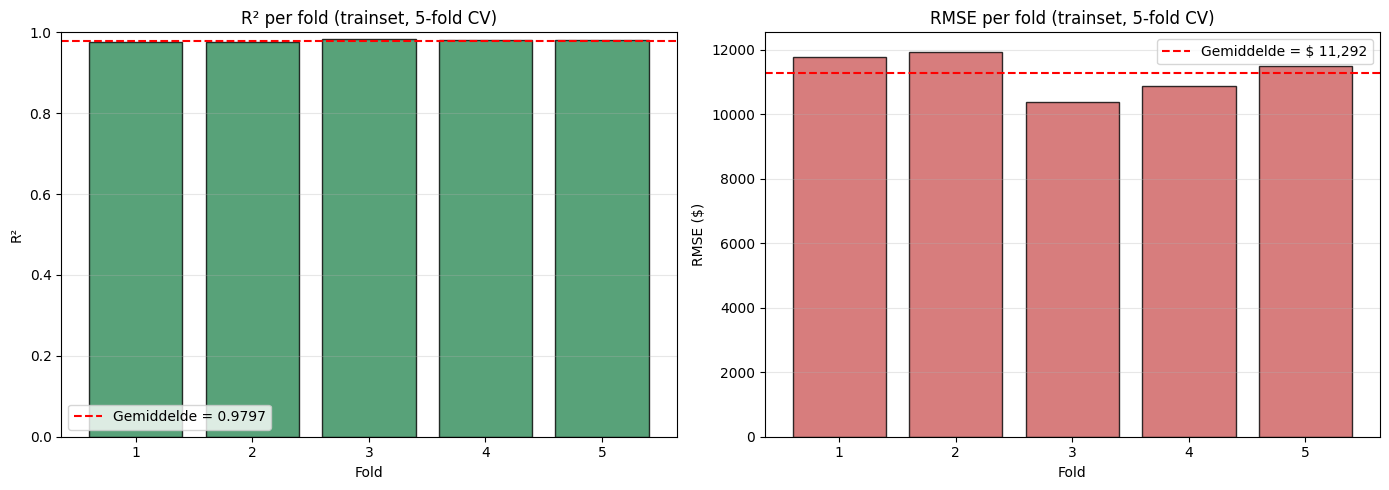

In [13]:
### K-Fold Cross-Validation — Random Forest (huizenprijzen) — alleen trainset

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# Data opnieuw inladen zodat deze cel zelfstandig werkt
DATA_DIR = 'house-prices-advanced-regression-techniques'
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

# Numerieke features bepalen (Id en target uitsluiten), net als in stap 4
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id', 'SalePrice']]

# Features + target; mediaan-imputatie voor missende numerieke waarden
X = train[num_cols].copy()
X = X.fillna(X.median(numeric_only=True))
y = train['SalePrice']

# 5-fold CV: shuffle aan + vaste random_state voor reproduceerbaarheid
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)

# cross_validate met twee metrieken; we tonen hieronder alleen de TRAIN-scores
cv_resultaten = cross_validate(
    rf, X, y,
    cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

# Alleen de train-scores (op de data waarop het model getraind is)
r2_train_scores   = cv_resultaten['train_r2']
rmse_train_scores = -cv_resultaten['train_neg_root_mean_squared_error']

print('Resultaten per fold (trainset):')
for i, (r2_f, rmse_f) in enumerate(zip(r2_train_scores, rmse_train_scores), start=1):
    print(f'  Fold {i}:  R² = {r2_f:.4f}   RMSE = $ {rmse_f:,.0f}')

print('\nGemiddelde over 5 folds (trainset):')
print(f'  R²   = {r2_train_scores.mean():.4f}  (± {r2_train_scores.std():.4f})')
print(f'  RMSE = $ {rmse_train_scores.mean():,.0f}  (± $ {rmse_train_scores.std():,.0f})')

# Visualisatie: R² en RMSE per fold — alleen trainset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = np.arange(1, len(r2_train_scores) + 1)

axes[0].bar(folds, r2_train_scores, color='seagreen', edgecolor='black', alpha=0.8)
axes[0].axhline(r2_train_scores.mean(), color='red', linestyle='--',
                label=f'Gemiddelde = {r2_train_scores.mean():.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_title('R² per fold (trainset, 5-fold CV)')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(folds, rmse_train_scores, color='indianred', edgecolor='black', alpha=0.8)
axes[1].axhline(rmse_train_scores.mean(), color='red', linestyle='--',
                label=f'Gemiddelde = $ {rmse_train_scores.mean():,.0f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE per fold (trainset, 5-fold CV)')
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Welke waarde van k kies je en waarom?

Fold 4 zal gekozen worden, want deze lijkt het meest op het gemiddelde van de 5 folds en hiermee doen we dus niet aan cherry picking

Lijkt het resultaat meer op de train of de testset?

Het resultaat zal het meest lijken op de trainset want deze is ook gebruikt voor de cross validation

### Underfit/Overfit

Maak een underfit model (slechte prestaties op train en test) en een overfit model (veel betere prestaties op train vergeleken met test). Leg uit (via tekst en een of meer visualisaties) hoe je dit kan zien.

Let op: je maakt hier expres slechte modellen om te zien hoe veel controle over het presteren van het model je kan krijgen en te leren wat de verschillende hyperparameters kunnen opleveren. 

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Het is gelukt om een underfit- een overfitmodel te maken en er wordt duidelijk uitgelegd waaraan je dat kan zien. De rol van de train en testset wordt duidelijk uitgelegd. De resultaten worden onderbouwd met goede vizualisaties."

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)

### Gridsearch

Pas GridSearchCV() toe op je model in scikit-learn, hiermee kan je de beste waarde voor je hyperparameters vinden. Let op: voor maximale punten moet je ook K-Fold Cross Validatie tegelijk gebruiken (wss in een pipeline...zie DataCamp).

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er is GridSearchCV() uitgevoerd en er wordt beargumenteerd waarom gekozen is voor bepaalde hyperparameters. Ook wordt benoemd welke hyperparameter uiteindelijk het beste lijkt te zijn en waarom, en er is besproken hoe k-foldcross validatie betrokken wordt in de GridSearchCV()."

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)

### Definitief Model (Regressie)

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er worden uitspraken gedaan over hoe goed de modellen werken. De onderbouwing is duidelijk en logisch. Ook is beargumenteerd waarom het model niet under- en overfit. Daarnaast komt naar voren waarom bepaalde features wel en niet in het uiteindelijke model zitten."

Test het model met de beste parameters op de testset. Hoe goed is het model?

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)

Upload de voorspelling naar Kaggle. Is de score volgens verwachting?

(beantwoord als Markdown)

# Deelopdracht 2/2 - Classificatie Model (Borstkanker)

Let op: de bedoeling is dat jullie hetzelfde classificatie algoritme van Opdracht 1 blijven gebruiken (dus niet een nieuwe). 

### Theorievragen

Kies twee verschillende prestatiemetrics voor jouw gekozen classificatie algoritme.
Begin met het beantwoorden van een aantal vragen over deze prestatiemetrics.

1. Waarom heb je deze prestatiemetrics gekozen?

2. Wat zijn de voor- en nadelen van de eerste prestatiemetric?

3. Wat zijn de voor- en nadelen van de tweede prestatiemetric?

#### Beantwoord nu een aantal vragen over hyperparameters voor jouw gekozen classificatie algoritme.

4. Welke hyperparameters in je model kun je instellen (aan welke knoppen kan je draaien)? 

5. Leg uit wat een verandering van de waarde met het model doet (per hyperparameter).

6. Wat zouden logische waarden kunnen zijn (per hyperparameter)?

## Code

Zoals bij Opdracht 1, voor het classificatie model kunnen jullie deze dataset gebruiken:

https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

Als je het niet al hebben gedaan, splits je dataset in een train en een test (validatie) set.

### Prestatiemetrics

Bereken 2 prestatiemetrics op de traindata en op de testdata. Zijn er grote verschillen? Zo ja, hoe zou dat kunnen komen?

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De prestatiemetrics van de modellen zijn berekend. Er wordt toegelicht wat waarde van de metric betekend. Voordelen en nadelen van de gekozen metrics worden benoemd."

Let op: Je kan deze vraag (en soortgelijke vragen hieronder) beantwoorden via zowel aanvullende Markdown cellen (voor tekstuele antwoorden) als Code cellen (voor jouw code zelf, met commentaar erbij). Gebruik gewoon wat je het best helpt om de vraag te beantwoorden. 

(voorbeeld Markdown cell)

In [ ]:
(voorbeeld Code cell)

### K-Fold Cross Validatie

Pas k-fold cross validation toe op de traindataset. Zie ook: https://scikit-learn.org/stable/modules/cross_validation.html

In [ ]:
(beantwoord als code)

Welke waarde van k kies je en waarom?

(beantwoord als Markdown)

Lijkt het resultaat meer op de train of de testset?

(beantwoord als Markdown)

### Underfit/Overfit

Maak een underfit model (slechte prestaties op train en test) en een overfit model (veel betere prestaties op train vergeleken met test). Leg uit (via tekst en een of meer visualisaties) hoe je dit kan zien. 

Let op: je maakt hier expres slechte modellen om te zien hoe veel controle over het presteren van het model je kan krijgen en te leren wat de verschillende hyperparameters kunnen opleveren. 

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Het is gelukt om een underfit- een overfitmodel te maken en er wordt duidelijk uitgelegd waaraan je dat kan zien. De rol van de train en testset wordt duidelijk uitgelegd. De resultaten worden onderbouwd met goede vizualisaties."

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)

### RandomizedSearch

Pas RandomizedSearchCV() toe op je model in scikit-learn, hiermee kan je de beste waarde voor je hyperparameters vinden. RandomizedSearchCV is een andere methode dan GridSearch. Zie hier voor meer informatie: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

Let op: voor maximale punten moet je ook K-Fold Cross Validatie tegelijk gebruiken (wss in een pipeline...zie DataCamp).

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er is RandomizedSearchCV() uitgevoerd en er wordt beargumenteerd waarom gekozen is voor bepaalde hyperparameters. Ook wordt benoemd welke hyperparameter uiteindelijk het beste lijkt te zijn en waarom, en er is besproken hoe k-foldcross validatie betrokken wordt in de RandomizedSearchCV()."

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)

### Definitief Model (Classificatie)

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er worden uitspraken gedaan over hoe goed de modellen werken. De onderbouwing is duidelijk en logisch. Ook is beargumenteerd waarom het model niet under- en overfit. Daarnaast komt naar voren waarom bepaalde features wel en niet in het uiteindelijke model zitten."

Test het model met de beste parameters op de testset. Hoe goed is het model?

In [ ]:
(beantwoord als code)

(beantwoord als Markdown)